# Midterm Quiz 2: Data Analysis using Pandas

## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Extract RT-IoT2022 Dataset

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\tipqc\.cache\kagglehub\datasets\supplejade\rt-iot2022real-time-internet-of-things\versions\3


In [15]:
rt_iot_df = pd.read_csv("RT_IOT2022.csv")
rt_iot_df.head()

,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


## Data Exploration

In [16]:
rt_iot_df.shape

(123117, 85)

In [17]:
rt_iot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   no                        123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  f

In [18]:
# Check column names
rt_iot_df.columns

Index(['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count',
       'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count',
       'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count',
       'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count',
       'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot',
       'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min',
       'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg',
       'bwd_pkts_payload.std', 'flow_pkts_payload.min',
       'flow_pkts_payload.max', 'flow_pkts_payload.tot',
  

In [19]:
rt_iot_df.isnull().sum().sort_values(ascending=False)

no                          0
bwd_iat.std                 0
bwd_subflow_pkts            0
fwd_subflow_pkts            0
payload_bytes_per_second    0
                           ..
bwd_URG_flag_count          0
fwd_URG_flag_count          0
flow_ACK_flag_count         0
bwd_PSH_flag_count          0
Attack_type                 0
Length: 85, dtype: int64

In [20]:
rt_iot_df['Attack_type'].value_counts()

Attack_type
DOS_SYN_Hping                 94659
Thing_Speak                    8108
ARP_poisioning                 7750
MQTT_Publish                   4146
NMAP_UDP_SCAN                  2590
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  534
Wipro_bulb                      253
Metasploit_Brute_Force_SSH       37
NMAP_FIN_SCAN                    28
Name: count, dtype: int64

## Data Transformation

In [21]:
# Copy original DataFrame
df = rt_iot_df.copy()

In [22]:
# Change column names to lowercase
df.columns = [col.lower() for col in df.columns]

In [23]:
# Remove dots in column names
df.columns = [col.replace('.', '_') for col in df.columns]
df.columns

Index(['no', 'id_orig_p', 'id_resp_p', 'proto', 'service', 'flow_duration',
       'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot',
       'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec',
       'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot',
       'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot',
       'bwd_header_size_min', 'bwd_header_size_max', 'flow_fin_flag_count',
       'flow_syn_flag_count', 'flow_rst_flag_count', 'fwd_psh_flag_count',
       'bwd_psh_flag_count', 'flow_ack_flag_count', 'fwd_urg_flag_count',
       'bwd_urg_flag_count', 'flow_cwr_flag_count', 'flow_ece_flag_count',
       'fwd_pkts_payload_min', 'fwd_pkts_payload_max', 'fwd_pkts_payload_tot',
       'fwd_pkts_payload_avg', 'fwd_pkts_payload_std', 'bwd_pkts_payload_min',
       'bwd_pkts_payload_max', 'bwd_pkts_payload_tot', 'bwd_pkts_payload_avg',
       'bwd_pkts_payload_std', 'flow_pkts_payload_min',
       'flow_pkts_payload_max', 'flow_pkts_payload_tot',
  

In [24]:
# Set 'attack_type' data name to lowercase
df['attack_type'] = df['attack_type'].str.lower()
df['attack_type']

0                mqtt_publish
1                mqtt_publish
2                mqtt_publish
3                mqtt_publish
4                mqtt_publish
                 ...         
123112    nmap_xmas_tree_scan
123113    nmap_xmas_tree_scan
123114    nmap_xmas_tree_scan
123115    nmap_xmas_tree_scan
123116    nmap_xmas_tree_scan
Name: attack_type, Length: 123117, dtype: object

## Data Visualization

### Top 5 Attack Types

Text(0, 0.5, 'Attack Type')

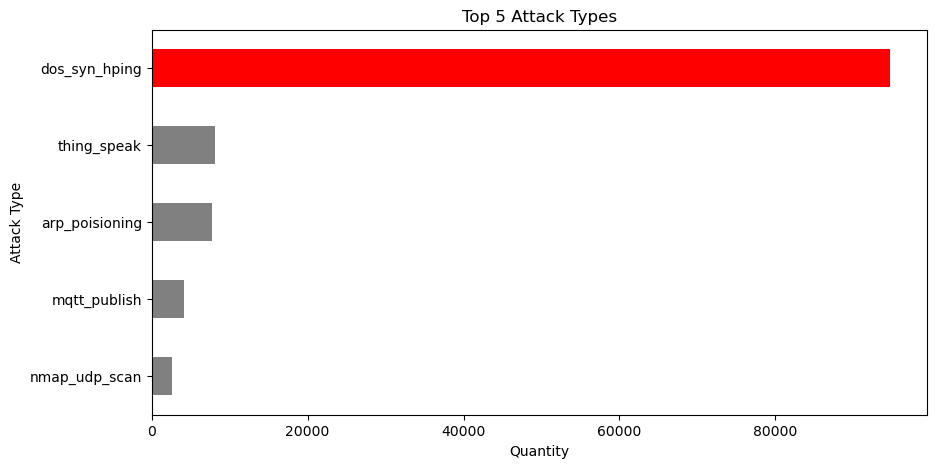

In [84]:
# Top 5 Attack Types Visualization
at_colors=['grey', 'grey', 'grey', 'grey', 'red']

df.attack_type.value_counts().iloc[4::-1].plot(
    kind='barh', figsize=(10, 5),
    title='Top 5 Attack Types',
    color=at_colors
)
plt.xlabel('Quantity')
plt.ylabel('Attack Type')

### Usual Flow Durations

Text(0, 0.5, 'Flow Duration')

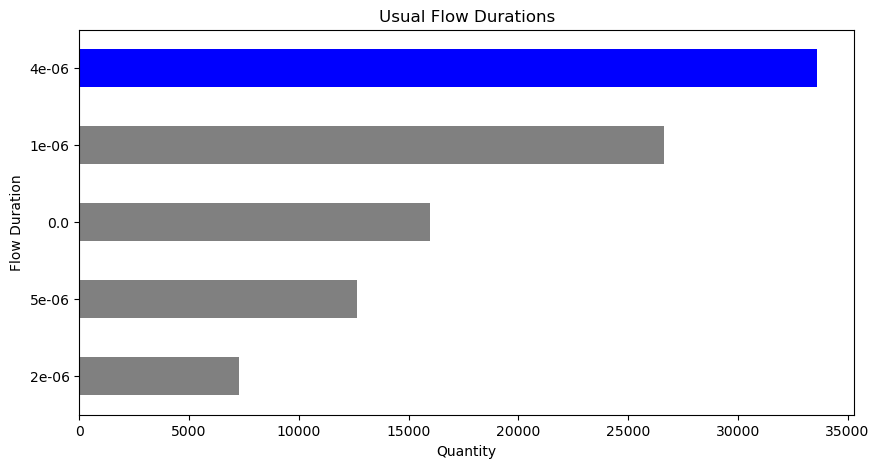

In [90]:
# Usual Flow Durations Visualization
at_colors=['grey', 'grey', 'grey', 'grey', 'blue']

df.flow_duration.value_counts().iloc[4::-1].plot(
    kind='barh', figsize=(10, 5),
    title='Usual Flow Durations',
    color=at_colors
)
plt.xlabel('Quantity')
plt.ylabel('Flow Duration')

# End